In [1]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# 2. Load dataset (upload the CSV to Colab first, or mount Drive)
from google.colab import files
uploaded = files.upload()   # choose student_placement_salary_elite_v2.csv

df = pd.read_csv('student_placement_salary_elite_v2.csv')

Saving student_placement_salary_elite_v2.csv to student_placement_salary_elite_v2.csv


In [3]:
print("Shape:", df.shape)
df.head()

Shape: (9000, 20)


,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


In [4]:
df.info()
df.describe(include='all').T
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   object 
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   object 
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   i

Placement distribution:
placed
1    7702
0    1298
Name: count, dtype: int64

Placement rate: 85.58%


/tmp/ipykernel_3317/1073685890.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='placed', data=df, palette='Set2')


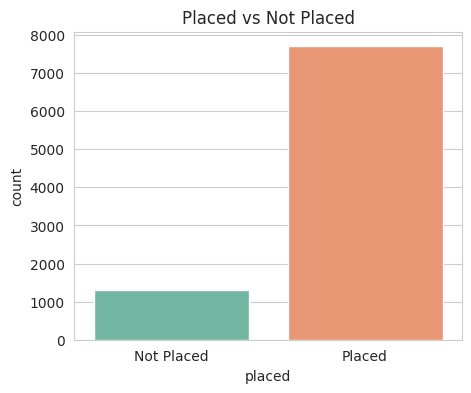

In [11]:
# Target 1: placed (classification)
print("Placement distribution:")
print(df['placed'].value_counts())
print("\nPlacement rate: {:.2f}%".format(df['placed'].mean() * 100))

plt.figure(figsize=(5,4))
sns.countplot(x='placed', data=df, palette='Set2')
plt.title('Placed vs Not Placed')
plt.xticks([0,1], ['Not Placed', 'Placed'])
plt.show()


Salary stats (placed students only):
count    7702.000000
mean       64.747312
std        17.035688
min        32.830000
25%        49.020000
50%        65.870000
75%        77.482500
max       129.430000
Name: salary_lpa, dtype: float64


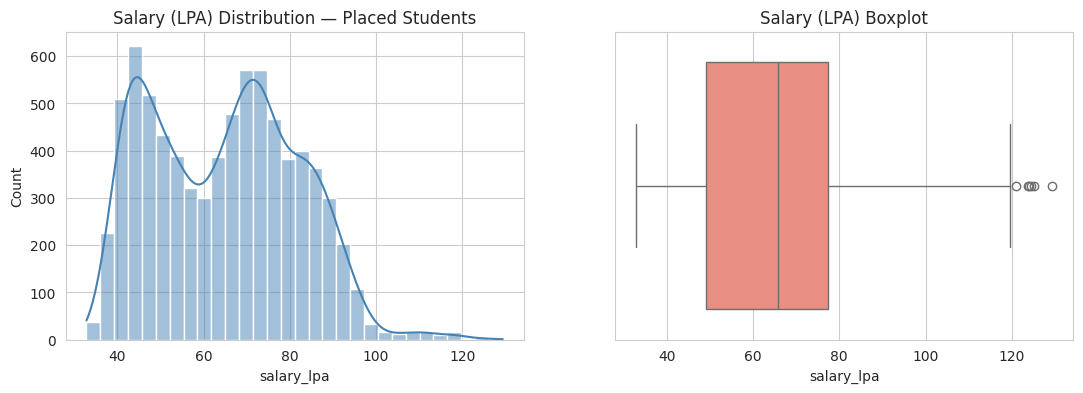

In [12]:
# Target 2: salary_lpa (regression) — only for placed students
placed_df = df[df['placed'] == 1]
print("\nSalary stats (placed students only):")
print(placed_df['salary_lpa'].describe())

fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(placed_df['salary_lpa'], kde=True, bins=30, color='steelblue', ax=ax[0])
ax[0].set_title('Salary (LPA) Distribution — Placed Students')
sns.boxplot(x=placed_df['salary_lpa'], color='salmon', ax=ax[1])
ax[1].set_title('Salary (LPA) Boxplot')
plt.show()

**Key Takeaways**


*   Average and median are very close so distribution is roughly symmetric
*   There's significant variation in packages.
*   Top 25% of students are getting 77.5 LPA and above

**Histogram**
*   Many students getting mid-tier offers (likely from Mid-size companies or Startups).
*   The majority of good offers (likely from MNCs and Top Tech)
*   Very few students below 40 LPA or above 110 LPA

**Boxplot**
*   ~49 to ~77 LPA is where the middle 50% of placed students fall.
*   Median line is around 66 LPA.
*   There are several outliers on the higher end (above ~110-120 LPA) — these are likely the students who got into Top Tech / Dream Companies.
*   No major lower outliers.

In [7]:
# 5. Unique values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False))

Categorical columns: ['student_id', 'branch', 'company_type', 'job_role']

--- student_id (9000 unique) ---
student_id
S8999    1
S0       1
S1       1
S2       1
S3       1
        ..
S12      1
S11      1
S10      1
S9       1
S8       1
Name: count, Length: 9000, dtype: int64

--- branch (6 unique) ---
branch
IT            1564
Civil         1504
ECE           1499
CSE           1496
EEE           1478
Mechanical    1459
Name: count, dtype: int64

--- company_type (4 unique) ---
company_type
MNC         3179
Startup     2230
Mid-size    2158
NaN         1298
Top Tech     135
Name: count, dtype: int64

--- job_role (4 unique) ---
job_role
Web Developer        1939
Data Scientist       1938
Software Engineer    1937
Analyst              1888
NaN                  1298
Name: count, dtype: int64


In [8]:
# Create a new feature
df['placed'] = df['placed'].astype(int)

# Fill NaN with meaningful values
df['company_type'] = df['company_type'].fillna('Not Placed')
df['job_role'] = df['job_role'].fillna('Not Placed')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   object 
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   object 
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   i

In [10]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False))

Categorical columns: ['student_id', 'branch', 'company_type', 'job_role']

--- student_id (9000 unique) ---
student_id
S8999    1
S0       1
S1       1
S2       1
S3       1
        ..
S12      1
S11      1
S10      1
S9       1
S8       1
Name: count, Length: 9000, dtype: int64

--- branch (6 unique) ---
branch
IT            1564
Civil         1504
ECE           1499
CSE           1496
EEE           1478
Mechanical    1459
Name: count, dtype: int64

--- company_type (5 unique) ---
company_type
MNC           3179
Startup       2230
Mid-size      2158
Not Placed    1298
Top Tech       135
Name: count, dtype: int64

--- job_role (5 unique) ---
job_role
Web Developer        1939
Data Scientist       1938
Software Engineer    1937
Analyst              1888
Not Placed           1298
Name: count, dtype: int64


In [13]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical columns:", numerical_cols)

for col in numerical_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False).sort_index())

Numerical columns: ['cgpa', 'college_tier', 'python_skill', 'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score', 'communication_score', 'aptitude_score', 'internships', 'projects', 'backlogs', 'resume_score', 'skill_score', 'placed', 'salary_lpa']

--- cgpa (501 unique) ---
cgpa
5.00      4
5.01     20
5.02     18
5.03     18
5.04      5
         ..
9.96     17
9.97     14
9.98     26
9.99     15
10.00    12
Name: count, Length: 501, dtype: int64

--- college_tier (3 unique) ---
college_tier
1    2960
2    2974
3    3066
Name: count, dtype: int64

--- python_skill (2 unique) ---
python_skill
0    3149
1    5851
Name: count, dtype: int64

--- dsa_skill (2 unique) ---
dsa_skill
0    4000
1    5000
Name: count, dtype: int64

--- ml_skill (2 unique) ---
ml_skill
0    6302
1    2698
Name: count, dtype: int64

--- web_dev_skill (2 unique) ---
web_dev_skill
0    5459
1    3541
Name: count, dtype: int64

--- coding_score (1001 unique) ---
coding_score
0.0       6
0.1      11
0.2      11
0